In [1]:
import tensorflow as tf

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

In [3]:
# Load MNIST Dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 38s 3us/step


In [4]:
# Normalize Data
x_train = x_train /255.0
x_test = x_test /255.0

In [5]:
# Build Model
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation ='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

c:\Users\Awadhesh Kumaar\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [6]:
# Compile model
model.compile(
    optimizer = 'adam',
    loss ='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [7]:
# Train Model
history = model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9217 - loss: 0.2630 - val_accuracy: 0.9595 - val_loss: 0.1376
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9650 - loss: 0.1133 - val_accuracy: 0.9701 - val_loss: 0.1048
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9754 - loss: 0.0784 - val_accuracy: 0.9682 - val_loss: 0.1008
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9819 - loss: 0.0568 - val_accuracy: 0.9710 - val_loss: 0.0996
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9853 - loss: 0.0470 - val_accuracy: 0.9678 - val_loss: 0.1119
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9762 - val_loss: 0.0883
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9901 - loss: 0.0296 - val_accuracy: 0.9758 - val_loss: 0.0940
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9915 - loss: 0.0258 - 

In [8]:
# Evaluate model
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"\n Test Accuracy:{test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9753 - loss: 0.1034

 Test Accuracy:0.9753


In [9]:
# Predict First Test Image
prediction = model.predict(x_test)
print("Predicted Digit:",prediction[0].argmax())
print("Actual Digit:",y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 979us/step
Predicted Digit: 7
Actual Digit: 7


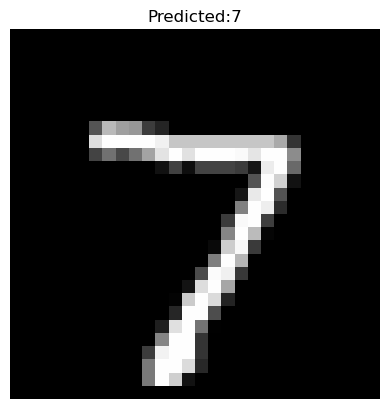

In [10]:
# Display Image
plt.imshow(x_test[0],cmap='gray')
plt.title(f"Predicted:{prediction[0].argmax()}")
plt.axis('off')
plt.show()